
# Lineares Ausgleichsproblem mit ASTRA: Shepp-Logan-Phantom und verschiedene Noiselevel

Wir lösen das lineare Ausgleichsproblem

$$
\min_x \|Ax-b\|_2^2,
$$

wobei \(A\) die diskretisierte Radonmatrix ist.  
Das Sinogramm \(b\) wird durch Vorwärtsprojektion des Shepp-Logan-Testphantoms simuliert und anschließend mit Gauß-Rauschen verschiedener Stärke verrauscht.

Getestete Noiselevel:

\[
0,\;1\%,\;2\%,\;4\%,\;8\%.
\]

Für jedes Noiselevel wird eine Rekonstruktion berechnet. Am Ende werden

- die Groundtruth,
- alle 5 Rekonstruktionen,
- sowie der Fehler in Abhängigkeit vom Noiselevel

geplottet.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

import astra 
from scipy.sparse.linalg import lsqr


# 0. Astra toolbox installieren

Die Astra toolbox kann mit 'pip install astra-toolbox' übers Terminal ( “New” → “Terminal”) installiert werden



## 1. Parameter festlegen

Für das explizite Least-Squares-Problem sollte die Bildgröße nicht zu groß gewählt werden, da iterative Verfahren wie `lsqr` viele Anwendungen von \(A\) und \(A^T\) benötigen.


In [2]:

# Bildgröße: N x N
N = 64

# Anzahl der Projektionswinkel
num_angles = 180

# Anzahl der Detektorpixel
num_detectors = 180

# Projektionswinkel von 0 bis pi
angles = np.linspace(0, np.pi, num_angles, endpoint=False)

# Noiselevel in Prozent
noise_levels_percent = [0,1,2,4,8]

# Noiselevel als Dezimalzahlen
noise_levels = [p / 100 for p in noise_levels_percent]



## 2. ASTRA-Geometrien und Radonoperator erstellen

Wir verwenden parallele Strahlengeometrie (`parallel`) und erzeugen daraus einen ASTRA-Projektor.  
Mit `astra.OpTomo(proj_id)` erhalten wir einen linearen Operator, der wie eine Matrix \(A\) verwendet werden kann.

Wichtig: Der Projektor `proj_id` darf während der Rechnung **nicht gelöscht** werden, da `OpTomo` intern darauf verweist.


In [3]:

# Volumengeometrie für ein N x N Bild
vol_geom = astra.create_vol_geom(N, N)

# Projektionsgeometrie: parallel beam
proj_geom = astra.create_proj_geom(
    'parallel',
    1.0,              # Detektorabstand
    num_detectors,
    angles
)

# Projektor erzeugen
# 'linear' ist CPU-basiert und funktioniert in der Regel ohne GPU.
proj_id = astra.create_projector('linear', proj_geom, vol_geom)

# Matrixfreier Radonoperator A
A = astra.OpTomo(proj_id)

print(A)
print("Operator shape:", A.shape)


<32400x4096 OpTomo with dtype=<class 'numpy.float32'>>
Operator shape: (32400, 4096)



## 3. Shepp-Logan-Phantom erzeugen

Das Phantom dient als Groundtruth $x_{\mathrm{true}}$.


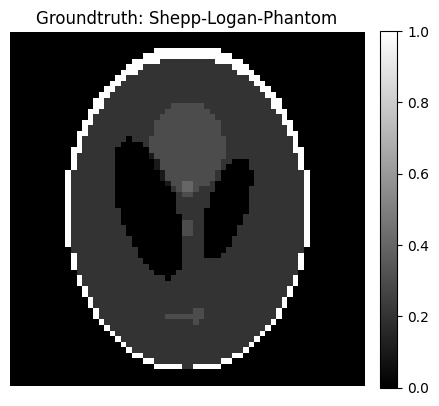

In [4]:

# ASTRA erzeugt direkt ein Shepp-Logan-Phantom
phantom_id, x_true_2d = astra.data2d.shepp_logan(vol_geom)

# Für das lineare Gleichungssystem brauchen wir einen Vektor
x_true = x_true_2d.ravel()

plt.figure(figsize=(5, 5))
plt.imshow(x_true_2d, cmap="gray")
plt.title("Groundtruth: Shepp-Logan-Phantom")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()



## 4. Rauschfreies Sinogramm berechnen

Das saubere Sinogramm wird berechnet durch

$$
b_{\mathrm{clean}} = A x_{\mathrm{true}}.
$$

Danach wird es für die Darstellung in Sinogramm-Form gebracht.


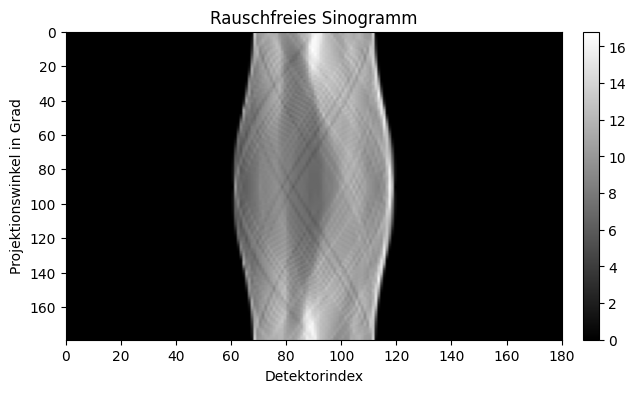

In [5]:

# Rauschfreies Sinogramm als Vektor
b_clean = A @ x_true # Laut der Formel

# Sinogramm-Form: Anzahl Winkel x Anzahl Detektoren
sinogram_clean = np.reshape(b_clean, (num_detectors, num_angles))

plt.figure(figsize=(7, 4))
plt.imshow(
    sinogram_clean,
    cmap="gray",
    aspect="auto",
    extent=[0, num_detectors, np.rad2deg(angles[-1]), 0]
)
plt.title("Rauschfreies Sinogramm")
plt.xlabel("Detektorindex")
plt.ylabel("Projektionswinkel in Grad")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()



## 5. Rekonstruktionen für verschiedene Noiselevel

Für jedes Noiselevel $\eta$ erzeugen wir

$$
b_\eta = b_{\mathrm{clean}} + \text{noise}.
$$

Das Rauschen (noise) soll standard normalverteilt und mit $\eta$ skaliert sein.

Anschließend lösen wir

$$
\min_x \|Ax-b_\eta\|_2^2
$$

zB mit `scipy.sparse.linalg.lsqr` oder den Codes vom letzten Semester.


In [6]:
reconstructions = []

# Ich gehe davon aus, der relative Fehler ist bzgl. der echten loesung (x_clean). 
errors_rel = [] 

x_true_magnitude = np.linalg.norm(x_true, ord=2)

rng = np.random.default_rng()
rng_vec = rng.standard_normal(size=b_clean.shape)

for noise_percent, noise_level in zip(noise_levels_percent, noise_levels):
    print(f"Noiselevel: {noise_percent:.1f}%")

    noise = noise_level * rng_vec
    x_rec, _, itn, r1norm = lsqr(A, b_clean + noise)[:4] 
    x_rec_2d = x_rec.reshape(x_true_2d.shape)

    rel_error = np.linalg.norm(x_rec.ravel() - x_true, ord=2) / x_true_magnitude

    # Ergebnisse speichern
    reconstructions.append(x_rec_2d)
    errors_rel.append(rel_error)


    print(f"  Relativer Fehler: {rel_error:.6e}")
    print()


Noiselevel: 0.0%
  Relativer Fehler: 3.241618e-03

Noiselevel: 1.0%
  Relativer Fehler: 1.795374e-02

Noiselevel: 2.0%
  Relativer Fehler: 3.587026e-02

Noiselevel: 4.0%
  Relativer Fehler: 7.198862e-02

Noiselevel: 8.0%
  Relativer Fehler: 1.438152e-01




## 6. Groundtruth und alle Rekonstruktionen plotten


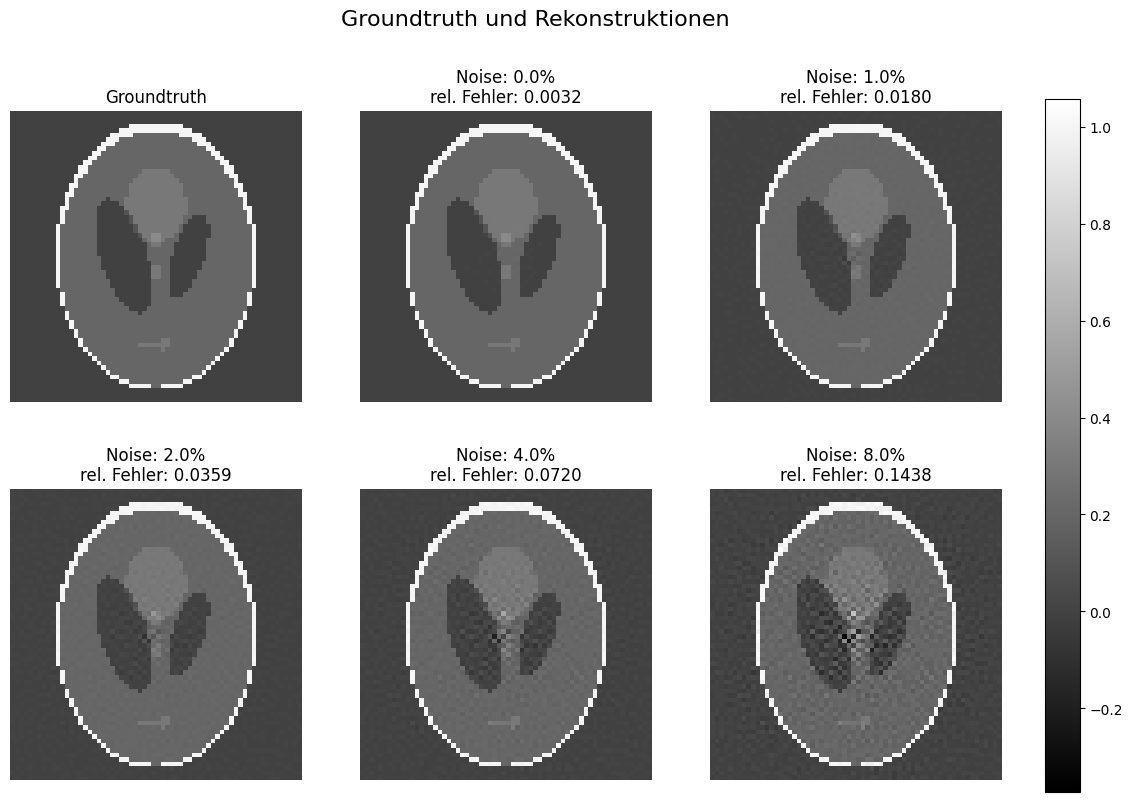

In [7]:

# Gemeinsame Farbskala für faire visuelle Vergleichbarkeit
vmin = min(x_true_2d.min(), *(rec.min() for rec in reconstructions))
vmax = max(x_true_2d.max(), *(rec.max() for rec in reconstructions))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Groundtruth
ax = axes[0, 0]
im = ax.imshow(x_true_2d, cmap="gray", vmin=vmin, vmax=vmax)
ax.set_title("Groundtruth")
ax.axis("off")

# Rekonstruktionen
for i, (rec, noise_percent, rel_error) in enumerate(
    zip(reconstructions, noise_levels_percent, errors_rel),
    start=1
):
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    ax.imshow(rec, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(
        f"Noise: {noise_percent:.1f}%\nrel. Fehler: {rel_error:.4f}"
    )
    ax.axis("off")

# Falls ein Achsenfeld übrig bleibt, ausblenden
for j in range(len(noise_levels_percent) + 1, 6):
    row = j // 3
    col = j % 3
    axes[row, col].axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
plt.suptitle("Groundtruth und Rekonstruktionen", fontsize=16)
plt.show()


## 7. Fehler in Abhängigkeit vom Noiselevel plotten

Wir plotten den relativen Fehler

$$
\frac{\|x_{\mathrm{rec}} - x_{\mathrm{true}}\|_2}
{\|x_{\mathrm{true}}\|_2}.
$$


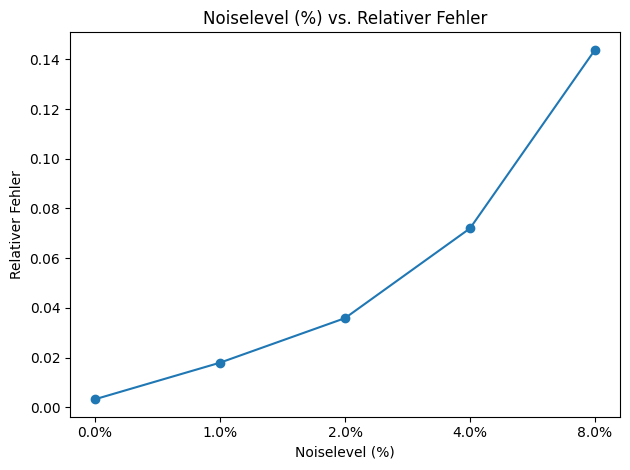

In [8]:

fig, plot1 = plt.subplots(1, 1)

y_vals = [f"{noise_percent:.1f}%" for noise_percent in noise_levels_percent]
plot1.plot(y_vals, errors_rel, marker='o')
plot1.set_title("Noiselevel (%) vs. Relativer Fehler")
plot1.set_xlabel("Noiselevel (%)")
plot1.set_ylabel("Relativer Fehler")

plt.tight_layout()
plt.show()
